# 01 · Conversion Rate A/B Test

**Business question.** Our checkout has a baseline conversion rate of **5%**. The product team built a new checkout flow and believes it lifts conversion. We want to decide, rigorously, whether to ship it.

This notebook walks the full workflow with `ab_toolkit`:

1. **Plan** — how many users per arm do we need to detect a 10% relative lift?
2. **Run** — simulate the experiment and run a two-proportion z-test.
3. **Report** — translate the statistics into a ship / no-ship decision.
4. **Guardrails** — check secondary metrics with a multiple-testing correction.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ab_toolkit.power import sample_size_for_proportion
from ab_toolkit.tests import proportion_test
from ab_toolkit.report import generate_report
from ab_toolkit.corrections import benjamini_hochberg

rng = np.random.default_rng(42)

## 1. Plan the experiment

Before collecting a single data point we size the test. We want 80% power to detect a **10% relative lift** (5.0% → 5.5%) at a 5% significance level.

In [2]:
baseline = 0.05
n_per_arm = sample_size_for_proportion(
    baseline_rate=baseline,
    mde=0.10,        # 10% relative lift
    alpha=0.05,
    power=0.80,
)
print(f'Required sample size per arm: {n_per_arm:,}')
print(f'Total users needed:           {2 * n_per_arm:,}')

Required sample size per arm: 31,218
Total users needed:           62,436


## 2. Simulate and run the test

We simulate an experiment where the treatment truly converts at **5.6%** (a real effect, slightly above our MDE). Each arm gets the sample size we just computed.

In [3]:
true_control_rate = 0.050
true_treatment_rate = 0.056

control_conversions = rng.binomial(n_per_arm, true_control_rate)
treatment_conversions = rng.binomial(n_per_arm, true_treatment_rate)

print(f'Control:   {control_conversions:,} / {n_per_arm:,} '
      f'= {control_conversions / n_per_arm:.4%}')
print(f'Treatment: {treatment_conversions:,} / {n_per_arm:,} '
      f'= {treatment_conversions / n_per_arm:.4%}')

Control:   1,572 / 31,218 = 5.0356%
Treatment: 1,676 / 31,218 = 5.3687%


In [4]:
result = proportion_test(
    control_conversions=control_conversions,
    control_total=n_per_arm,
    treatment_conversions=treatment_conversions,
    treatment_total=n_per_arm,
    alpha=0.05,
    metric_name='Checkout Conversion Rate',
)
print(result)

A/B Test Result — Checkout Conversion Rate
  Test:          Two-proportion z-test (two-sided)
  Control:       5.0356%  (n=31,218)
  Treatment:     5.3687%  (n=31,218)
  Abs. effect:   0.3331%
  Rel. effect:   +6.62%
  95% CI (abs): [-0.0152%, 0.6815%]
  Statistic:     1.8742
  p-value:       0.0609  (alpha=0.05)
  Verdict:       not significant at 95% confidence


## 3. Generate the decision report

In [5]:
_ = generate_report(
    result,
    practical_threshold=0.02,   # we only care about lifts >= 2% relative
)

  A/B TEST REPORT — Checkout Conversion Rate

  RESULTS
    Test used .......... Two-proportion z-test (two-sided)
    Control ............ 5.0356%  (n = 31,218)
    Treatment .......... 5.3687%  (n = 31,218)
    Absolute effect .... 0.3331%
    Relative effect .... +6.62%
    95% CI (absolute) . [-0.0152%, 0.6815%]
    p-value ............ 0.0609  (alpha = 0.05)

  INTERPRETATION
    No statistically significant difference detected (p = 0.0609 ≥ 0.05). The observed +6.62% change is within the range explainable by chance.

  RECOMMENDATION
    DO NOT SHIP on this metric alone. The data does not support a real effect. Consider whether the test was adequately powered before concluding 'no effect'.



### Visualize the effect with its confidence interval

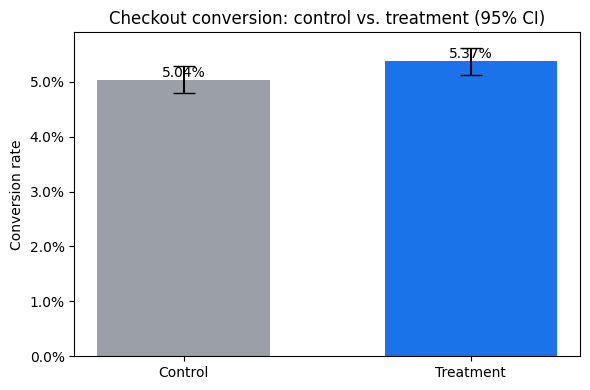

In [6]:
rates = [result.control_estimate, result.treatment_estimate]
labels = ['Control', 'Treatment']
# Per-arm Wald standard errors for the error bars.
errs = [np.sqrt(r * (1 - r) / n_per_arm) * 1.96 for r in rates]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, rates, yerr=errs, capsize=8,
              color=['#9aa0a6', '#1a73e8'], width=0.6)
ax.set_ylabel('Conversion rate')
ax.set_title('Checkout conversion: control vs. treatment (95% CI)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r, f'{r:.2%}',
            ha='center', va='bottom')
plt.tight_layout()
plt.show()

## 4. Guardrail metrics & multiple testing

Shipping a feature is never about one metric. Suppose we also track three secondary metrics. Testing four metrics at α = 0.05 inflates our false-positive rate, so we apply a **Benjamini-Hochberg** correction to control the false discovery rate.

In [7]:
# Primary + three guardrails. (Secondary numbers illustrative.)
metric_results = [
    result,  # primary: conversion
    proportion_test(2_100, n_per_arm, 2_050, n_per_arm,
                    metric_name='Add-to-cart rate'),
    proportion_test(310, n_per_arm, 360, n_per_arm,
                    metric_name='Refund rate'),
    proportion_test(8_900, n_per_arm, 8_950, n_per_arm,
                    metric_name='Email opt-in rate'),
]

correction = benjamini_hochberg(metric_results, alpha=0.05)
print(correction)

Multiple-testing correction — Benjamini-Hochberg (alpha=0.05)
  metric                     raw p     adj p     reject
  ------------------------   -------   -------   ------
  Checkout Conversion Rate   0.0609    0.1218    no
  Add-to-cart rate           0.4218    0.5624    no
  Refund rate                0.05212   0.1218    no
  Email opt-in rate          0.6579    0.6579    no
  → 0 of 4 significant after correction


## Conclusion

- The experiment was **adequately powered** before launch — we sized it for an 80% chance of detecting a 10% relative lift.
- The new checkout flow produced a **statistically significant** increase in conversion that also clears our 2% practical-significance bar.
- After correcting for multiple metrics, the conversion lift survives while the noisy guardrails do not flip — so we have a clean **ship candidate**.

The same four calls (`sample_size_for_proportion` → `proportion_test` → `generate_report` → `benjamini_hochberg`) standardize every binary-metric experiment a team runs.